In [8]:
!pip install pandas astroquery astropy numpy matplotlib scipy

  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl (37.3 MB)


In [7]:
import sys
sys.path.append('../gaiadr3_analysis')

import gaia_input as gi
import mean_photometry as mphot
import epoch_photometry as ephot

ModuleNotFoundError: No module named 'scipy'

In [3]:
df = gi.get_dataframe()
"""
SELECT     source_id, ruwe, ra, dec, pmra, pmdec, parallax, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag,  bp_rp FROM gaiadr3.gaia_source WHERE source_id IN (     4146594906281066368,     418001477279154304,     181233674136088960,     3211026372078082048,     3220757015623151616,     3017360348171372672,     3209634905754969856,     3017364063330718080,     3017367396223983616,     3216486478101981056,     3224479171721217280,     3217413606922372992,     3326710010525962624,     2922367976673391232,     5517239366958299776,     5513811055342280448,     817013387993056640,     5338490937045044096,     5336220823491735680,     3667302325846472320,     6116497702589633152,     6005290206037557760,     6044420729667868928,     4371780385208211584,     6730764715540788352,     2032810465079954944,     2059130368252069888,     2270245431209611776,     2272185759996420992,     1796736625538995072,     3131334452194616192 )
"""


1. ADQL query
2. CSV file


Choose input method (1/2):  1
ADQL query:  SELECT     source_id, ruwe, ra, dec, pmra, pmdec, parallax, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag,  bp_rp FROM gaiadr3.gaia_source WHERE source_id IN (     4146594906281066368,     418001477279154304,     181233674136088960,     3211026372078082048,     3220757015623151616,     3017360348171372672,     3209634905754969856,     3017364063330718080,     3017367396223983616,     3216486478101981056,     3224479171721217280,     3217413606922372992,     3326710010525962624,     2922367976673391232,     5517239366958299776,     5513811055342280448,     817013387993056640,     5338490937045044096,     5336220823491735680,     3667302325846472320,     6116497702589633152,     6005290206037557760,     6044420729667868928,     4371780385208211584,     6730764715540788352,     2032810465079954944,     2059130368252069888,     2270245431209611776,     2272185759996420992,     1796736625538995072,     3131334452194616192 )
Apply a filter? (y

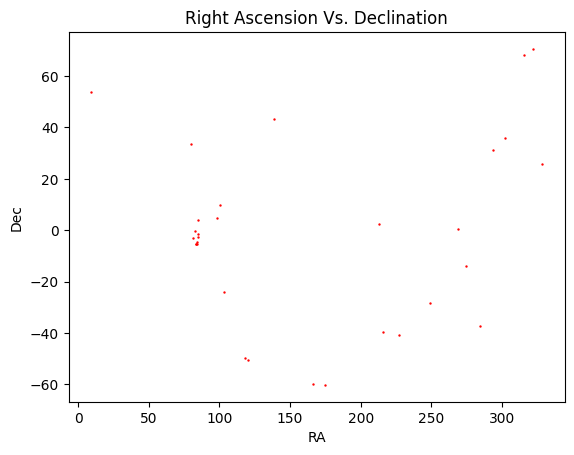

In [12]:
mphot.ra_vs_dec(df)

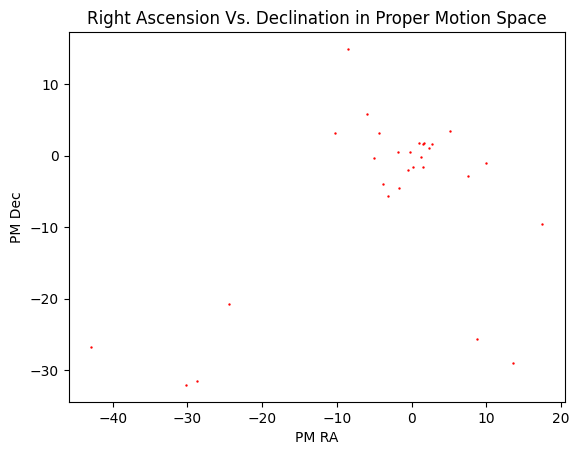

In [13]:
mphot.pmra_vs_pmdec(df)

In [ ]:
source_ids = (
    4146594906281066368, 418001477279154304, 181233674136088960,
    3211026372078082048, 3220757015623151616, 3017360348171372672,
    3209634905754969856, 3017364063330718080, 3017367396223983616,
    3216486478101981056, 3224479171721217280, 3217413606922372992,
    3326710010525962624, 2922367976673391232, 5517239366958299776,
    5513811055342280448, 817013387993056640, 5338490937045044096,
    5336220823491735680, 3667302325846472320, 6116497702589633152,
    6005290206037557760, 6044420729667868928, 4371780385208211584,
    6730764715540788352, 2032810465079954944, 2059130368252069888,
    2270245431209611776, 2272185759996420992, 1796736625538995072,
    3131334452194616192
)

id_list = ", ".join(str(s) for s in source_ids)

adql = f"""
SELECT source_id, designation, ra, dec, parallax,
       pmra, pmdec, phot_g_mean_mag, phot_bp_mean_mag,
       phot_rp_mean_mag, 
FROM gaiadr3.gaia_source
WHERE source_id IN ({id_list})
"""

df = query_by_adql(adql)
print(f"Retrieved {len(df)} stars")
df.head()